# GTM Visualization of Peptide WAE Latent Space

This notebook implements Generative Topographic Mapping (GTM) visualization for the Peptide WAE latent space using ChemographyKit.

GTM provides interpretable 2D projections of high-dimensional latent spaces with:
- Smooth, continuous mappings
- Density estimation
- Mode identification
- Region-based sampling capabilities

**Before Running**: Update the model path in cell 3 to point to your trained WAE model. The default path assumes a model in `output/wae_unlabeled_batch32/`.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# UMAP import (optional)
try:
    import umap
    print("UMAP imported successfully")
except ImportError as e:
    umap = None
    print(f"Warning: UMAP import failed: {e}")
from tqdm.auto import tqdm

# ChemographyKit imports
try:
    from chemographykit import gtm
    from chemographykit.gtm import GTM
    from chemographykit.utils.density import get_density_matrix, density_to_table
    from chemographykit.utils.regression import get_reg_density_matrix, norm_reg_density, reg_density_to_table
    from chemographykit.plots.plotly_landscapes import (
        plotly_smooth_density_landscape,
        plotly_smooth_regression_landscape
    )
    from chemographykit.plots.altair_landscapes import (
        altair_discrete_density_landscape,
        altair_discrete_regression_landscape,
        altair_points_chart
    )
    print("ChemographyKit imported successfully")
except ImportError as e:
    print(f"Warning: ChemographyKit import failed: {e}")
    print("Install with: uv pip install git+https://github.com/Laboratoire-de-Chemoinformatique/ChemographyKit.git")

# deepchemography imports
from deepchemography.peptides import (
    PeptideWAE, PeptideVocab, load_peptide_model,
    encode_peptide, decode_latent, sample_peptides, get_default_config,
)

# Plotting settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

print("All imports successful")

ChemographyKit imported successfully
All imports successful


In [25]:
# Configuration
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Model path - update this to point to your trained WAE model
WAE_MODEL_PATH = project_root / 'models' / 'peptides' / 'model_344000.pt'

# Data paths
DATA_DIR = project_root / 'data'
RESULTS_DIR = project_root / 'output' / 'sampling_analysis' / 'peptides_gtm_analysis'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# GTM parameters - Updated for ChemographyKit API
GTM_CONFIG = {
    'num_nodes': 900,  # 30x30 grid (15*15)
    'num_basis_functions': 100,  # 10x10 basis grid (10*10)
    'basis_width': 1,  # RBF width
    'reg_coeff': 100,  # Regularization coefficient
    'max_iter': 200,  # Maximum EM iterations
    'seed': 42,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"WAE model path: {WAE_MODEL_PATH}")
print(f"WAE model exists: {WAE_MODEL_PATH.exists() if WAE_MODEL_PATH else 'Path not set'}")
print(f"Results directory: {RESULTS_DIR}")

Using device: cuda
WAE model path: /data/aorlov/deepchemography/models/peptides/model_344000.pt
WAE model exists: True
Results directory: /data/aorlov/deepchemography/output/sampling_analysis/peptides_gtm_analysis


## 2. Data Preparation

Load the trained WAE model and extract latent representations.

In [26]:
# Load WAE model using deepchemography API
print("Loading WAE model...")

wae_model, wae_vocab = load_peptide_model(str(WAE_MODEL_PATH), device=str(DEVICE))
print(f"Loaded WAE model - Latent dim: {wae_model.z_dim}")
print(f"Vocabulary size: {wae_vocab.size()}")

2026-02-08 11:43:25,297 - deepchemography.peptides.api - WARNING - Vocab file not found at /data/aorlov/deepchemography/models/peptides/vocab.dict, using default vocab
2026-02-08 11:43:25,329 - deepchemography.peptides.api - INFO - Loaded model from /data/aorlov/deepchemography/models/peptides/model_344000.pt


Loading WAE model...
Loaded WAE model - Latent dim: 100
Vocabulary size: 26


In [27]:
# Load dataset
# Get the dataset path from cfg
DATA_ROOT = project_root / 'data'
dataset_path = DATA_ROOT / 'allDBs_short_peps_unlabeled.csv'

print(f"Dataset path: {dataset_path}")
print(f"Dataset exists: {dataset_path.exists()}")

Dataset path: /data/aorlov/deepchemography/data/allDBs_short_peps_unlabeled.csv
Dataset exists: True


In [48]:
# Extract latent vectors from WAE model

if dataset_path.exists():
    df = pd.read_csv(dataset_path)
    # Take a sample for faster computation (remove .sample() to use full dataset)
    df_sample = df.sample(n=min(50000, len(df)), random_state=42)
    sequences = df_sample['text'].tolist()
    print(f"Loaded {len(sequences)} sequences")
    print(f"Example sequence: {sequences[0]}")
else:
    print("Dataset not found. Creating dummy data for demonstration.")
    sequences = ["A L A G L Y", "G L Y A L A", "V A L I L E"] * 100

print("\nExtracting WAE latent vectors...")
z_list = []
for seq in tqdm(sequences, desc="Encoding"):
    z = encode_peptide(wae_model, wae_vocab, seq, sample_q='max')
    z_list.append(z.cpu().numpy())
z_wae = np.vstack(z_list)

print(f"Encoding complete!")
print(f"  WAE latent shape: {z_wae.shape}")
print(f"  Number of sequences: {len(sequences)}")

Loaded 50000 sequences
Example sequence: M T R I R R G Y I

Extracting WAE latent vectors...


Encoding:   0%|          | 0/50000 [00:00<?, ?it/s]

Encoding complete!
  WAE latent shape: (50000, 100)
  Number of sequences: 50000


In [49]:
# Standardize latent vectors for GTM
scaler_wae = StandardScaler()
z_wae_scaled = scaler_wae.fit_transform(z_wae)

print("Latent vector statistics after scaling:")
print(f"WAE - Mean: {z_wae_scaled.mean():.4f}, Std: {z_wae_scaled.std():.4f}")

Latent vector statistics after scaling:
WAE - Mean: -0.0000, Std: 1.0000


## 3. Train GTM Model

Train a GTM model on the WAE latent space.

In [50]:
# Train GTM on WAE latent space
print("Training GTM on WAE latent space...")

# Convert numpy to torch tensor (ChemographyKit requires torch tensors)
z_wae_tensor = torch.from_numpy(z_wae_scaled).to(dtype=torch.float64)

gtm_wae = GTM(
    num_nodes=GTM_CONFIG['num_nodes'],
    num_basis_functions=GTM_CONFIG['num_basis_functions'],
    basis_width=GTM_CONFIG['basis_width'],
    reg_coeff=GTM_CONFIG['reg_coeff'],
    max_iter=GTM_CONFIG['max_iter'],
    seed=GTM_CONFIG['seed'],
    device=GTM_CONFIG['device']
)

gtm_wae.fit(z_wae_tensor)

print("\nGTM training complete!")

# Get log-likelihood by projecting the data
responsibilities_wae, llhs_wae = gtm_wae.project(z_wae_tensor)
avg_log_likelihood = llhs_wae.mean().item()
print(f"Average log-likelihood: {avg_log_likelihood:.4f}")

Training GTM on WAE latent space...


  0%|          | 0/200 [00:00<?, ?it/s]

2026-02-08 11:45:27,866 - root - INFO - LLh: -173.44352 deltaLLh: 173.44352 beta: 2.94556
2026-02-08 11:45:28,285 - root - INFO - LLh: -137.51896 deltaLLh: 35.92456 beta: 1.13024
2026-02-08 11:45:28,701 - root - INFO - LLh: -136.6354 deltaLLh: 0.88356 beta: 1.15597
2026-02-08 11:45:29,118 - root - INFO - LLh: -135.96964 deltaLLh: 0.66575 beta: 1.18269
2026-02-08 11:45:29,535 - root - INFO - LLh: -135.37911 deltaLLh: 0.59054 beta: 1.20789
2026-02-08 11:45:29,951 - root - INFO - LLh: -134.97184 deltaLLh: 0.40726 beta: 1.22882
2026-02-08 11:45:30,368 - root - INFO - LLh: -134.71083 deltaLLh: 0.26101 beta: 1.24278
2026-02-08 11:45:30,783 - root - INFO - LLh: -134.54999 deltaLLh: 0.16084 beta: 1.25151
2026-02-08 11:45:31,200 - root - INFO - LLh: -134.4488 deltaLLh: 0.10119 beta: 1.25678
2026-02-08 11:45:31,617 - root - INFO - LLh: -134.37638 deltaLLh: 0.07242 beta: 1.26025
2026-02-08 11:45:32,033 - root - INFO - LLh: -134.31889 deltaLLh: 0.05749 beta: 1.26282
2026-02-08 11:45:32,450 - root 


GTM training complete!
Average log-likelihood: -133.4548


In [51]:
# Project data points to GTM space (get responsibilities)
print("Projecting data to GTM space...")

# Get mode (MAP estimate) for each point - transform returns latent coordinates
gtm_coords_wae = gtm_wae.transform(z_wae_tensor).cpu().numpy()

# Convert responsibilities to numpy (already computed during training)
responsibilities_wae = responsibilities_wae.cpu().numpy()

print(f"WAE GTM coordinates shape: {gtm_coords_wae.shape}")
print(f"WAE Responsibilities shape: {responsibilities_wae.shape}")

Projecting data to GTM space...
WAE GTM coordinates shape: (50000, 2)
WAE Responsibilities shape: (50000, 900)


## 4. Visualize GTM Maps

Create 2D projections colored by various properties.

In [52]:
# Create DataFrame for visualization
df_wae = pd.DataFrame({
    'gtm_x': gtm_coords_wae[:, 0],
    'gtm_y': gtm_coords_wae[:, 1],
    'model': 'WAE'
})

# Add sequences
df_wae['sequence'] = sequences

print("Created visualization DataFrame")
print(f"WAE points: {len(df_wae)}")

Created visualization DataFrame
WAE points: 50000


In [53]:
# Compute peptide properties for coloring
def compute_peptide_properties(sequences):
    """Compute basic peptide properties."""
    properties = {
        'length': [],
        'hydrophobicity': [],
        'charge': []
    }
    
    # Simplified hydrophobicity scale
    hydrophobic_aas = set('AILMFWYV')
    charged_positive = set('KR')
    charged_negative = set('DE')
    
    for seq in sequences:
        if not seq:
            properties['length'].append(0)
            properties['hydrophobicity'].append(0)
            properties['charge'].append(0)
            continue
        
        properties['length'].append(len(seq))
        
        # Fraction of hydrophobic residues
        hydrophobic_count = sum(1 for aa in seq if aa in hydrophobic_aas)
        properties['hydrophobicity'].append(hydrophobic_count / len(seq) if len(seq) > 0 else 0)
        
        # Net charge
        pos_charge = sum(1 for aa in seq if aa in charged_positive)
        neg_charge = sum(1 for aa in seq if aa in charged_negative)
        properties['charge'].append(pos_charge - neg_charge)
    
    return properties

props_wae = compute_peptide_properties(sequences)
for key, values in props_wae.items():
    df_wae[key] = values

print("Computed peptide properties:")
print(df_wae[['length', 'hydrophobicity', 'charge']].describe())

Computed peptide properties:
             length  hydrophobicity        charge
count  50000.000000    50000.000000  50000.000000
mean      36.990440        0.221131      0.700700
std        9.897565        0.071998      2.457584
min       11.000000        0.000000    -21.000000
25%       29.000000        0.172414     -1.000000
50%       39.000000        0.219512      1.000000
75%       45.000000        0.265306      2.000000
max       49.000000        0.533333     23.000000


In [54]:
# Interactive GTM visualization with Plotly - WAE using ChemographyKit landscapes

properties = ['length', 'hydrophobicity', 'charge']
landscape_positions = [('density', 1, 1), ('length', 1, 2), ('hydrophobicity', 2, 1), ('charge', 2, 2)]

print("Creating ChemographyKit landscape visualizations for WAE...")

# Compute density using ChemographyKit utilities
density_wae_vec = get_density_matrix(responsibilities_wae)
density_table_wae = density_to_table(
    density_wae_vec,
    node_threshold=0.01,
    output_csv_file=None
)

# Create smooth density landscape
fig_density_wae = plotly_smooth_density_landscape(
    density_table_wae,
    node_threshold=0.01,
    use_smooth=True,
    title="WAE GTM Density Landscape",
    width=800,
    height=800,
    background_color="white"
)

# Create regression landscapes for peptide properties
figs_wae = {'density': fig_density_wae}

for prop in properties:
    if prop in df_wae.columns:
        # Compute regression density
        reg_values = df_wae[prop].values
        density, reg_density = get_reg_density_matrix(responsibilities_wae, list(reg_values))

        # Convert to table
        reg_table = reg_density_to_table(
            density,
            reg_density,
            node_threshold=0.01,
            output_csv_file=None
        )

        # Create smooth regression landscape
        fig = plotly_smooth_regression_landscape(
            reg_table,
            colorset='Viridis',
            title=f"WAE GTM {prop.capitalize()} Landscape",
            width=800,
            height=800,
            background_color="white",
            use_smooth=True
        )

        figs_wae[prop] = fig

# Create combined figure with subplots
fig_combined_wae = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Density', 'Length', 'Hydrophobicity', 'Charge'),
    specs=[[{'type': 'heatmap'}, {'type': 'heatmap'}],
           [{'type': 'heatmap'}, {'type': 'heatmap'}]],
    horizontal_spacing=0.12,
    vertical_spacing=0.12
)

# Add landscapes to subplots
for prop, row, col in landscape_positions:
    if prop in figs_wae:
        for trace in figs_wae[prop].data:
            fig_combined_wae.add_trace(trace, row=row, col=col)

fig_combined_wae.update_layout(
    title_text="WAE GTM Property Landscapes (ChemographyKit)",
    height=1200,
    width=1200,
    showlegend=False
)

# Update axes
for i in range(1, 3):
    for j in range(1, 3):
        fig_combined_wae.update_xaxes(title_text="GTM X", row=i, col=j)
        fig_combined_wae.update_yaxes(title_text="GTM Y", row=i, col=j)

# Save
output_path_wae = RESULTS_DIR / 'gtm_wae_properties.html'
fig_combined_wae.write_html(str(output_path_wae))
print(f"Saved interactive plot to {output_path_wae}")

# Show
fig_combined_wae.show()

# Save individual landscapes
for prop, fig in figs_wae.items():
    fig.write_html(str(RESULTS_DIR / f'gtm_wae_{prop}_landscape.html'))
    print(f"Saved {prop} landscape to gtm_wae_{prop}_landscape.html")

Creating ChemographyKit landscape visualizations for WAE...
Saved interactive plot to /data/aorlov/deepchemography/output/sampling_analysis/peptides_gtm_analysis/gtm_wae_properties.html


Saved density landscape to gtm_wae_density_landscape.html
Saved length landscape to gtm_wae_length_landscape.html
Saved hydrophobicity landscape to gtm_wae_hydrophobicity_landscape.html
Saved charge landscape to gtm_wae_charge_landscape.html


## 5. Landscape Analysis

Analyze density maps, responsibility patterns, and identify modes in the GTM space.

In [55]:
# Compute density map (number of points per GTM node) using ChemographyKit

print("Computing density maps using ChemographyKit utilities...")

# Reshape to grid for compatibility with existing code
k_wae = int(np.sqrt(len(density_wae_vec)))
density_wae = density_wae_vec.reshape(k_wae, k_wae)

print(f"WAE density range: {density_wae.min():.2f} - {density_wae.max():.2f}")
print(f"WAE density shape: {density_wae.shape}")

Computing density maps using ChemographyKit utilities...
WAE density range: 6.07 - 237.75
WAE density shape: (30, 30)


In [56]:
# Visualize density map using ChemographyKit landscape

print("Creating publication-quality density landscape...")

# Create Altair static landscape for publication
chart_wae = altair_discrete_density_landscape(
    density_table_wae,
    title="WAE GTM Density Landscape"
)

# Save as HTML
altair_wae_path = RESULTS_DIR / 'gtm_density_wae_altair.html'
chart_wae.save(str(altair_wae_path))

print(f"Saved Altair density landscape to: {altair_wae_path}")

# Display (works in Jupyter)
from IPython.display import display
print("WAE Density Landscape (Altair):")
display(chart_wae)

# Also show Plotly version
fig_density_wae.show()

Creating publication-quality density landscape...
Saved Altair density landscape to: /data/aorlov/deepchemography/output/sampling_analysis/peptides_gtm_analysis/gtm_density_wae_altair.html
WAE Density Landscape (Altair):


alt.Chart(...)

In [57]:
# 3D PCA Projection of GTM Manifold in WAE Latent Space

# Get PCA eigenvectors from the GTM model (computed on the training data)
eigenvectors, eigenvalues = gtm_wae._get_pca(z_wae_tensor)

# Project GTM nodes to 3D PCA space
# phi @ weights maps latent grid nodes -> data space (num_nodes, num_features)
nodes_data_space = gtm_wae.phi @ gtm_wae.weights
nodes_pca3 = (nodes_data_space @ eigenvectors[:3].T).cpu().numpy()

# Project latent data points to 3D PCA space (subsample for performance)
n_display = min(5000, len(z_wae_tensor))
rng = np.random.default_rng(42)
display_idx = rng.choice(len(z_wae_tensor), size=n_display, replace=False)
z_display = z_wae_tensor[display_idx].to(dtype=torch.float64, device=eigenvectors.device)
data_pca3 = (z_display @ eigenvectors[:3].T).cpu().numpy()

# Build 3D plotly figure
fig = go.Figure()

# GTM nodes (red markers with hover labels)
fig.add_trace(go.Scatter3d(
    x=nodes_pca3[:, 0], y=nodes_pca3[:, 1], z=nodes_pca3[:, 2],
    mode='markers',
    marker=dict(size=3, color='red'),
    text=[f"Node {i}" for i in range(len(nodes_pca3))],
    hoverinfo='text',
    name='GTM Nodes'
))

# Latent data points (black markers)
fig.add_trace(go.Scatter3d(
    x=data_pca3[:, 0], y=data_pca3[:, 1], z=data_pca3[:, 2],
    mode='markers',
    marker=dict(size=1, color='black'),
    name='Latent Points'
))

fig.update_layout(
    scene=dict(xaxis_title='PCA 1', yaxis_title='PCA 2', zaxis_title='PCA 3'),
    title='3D PCA Projection of WAE Latent Space with GTM Nodes',
    width=800,
    height=800
)

output_path = RESULTS_DIR / 'gtm_wae_3d_pca.html'
fig.write_html(str(output_path))
print(f"Saved 3D PCA visualization to {output_path}")

fig.show()

Saved 3D PCA visualization to /data/aorlov/deepchemography/output/sampling_analysis/peptides_gtm_analysis/gtm_wae_3d_pca.html


In [38]:
# Identify modes (high-density regions)
def identify_modes(density_grid, threshold_percentile=90):
    """Identify high-density modes in GTM space."""
    threshold = np.percentile(density_grid, threshold_percentile)
    modes = density_grid > threshold
    
    # Get coordinates of modes
    mode_coords = np.argwhere(modes)
    mode_densities = [density_grid[coord[0], coord[1]] for coord in mode_coords]
    
    return mode_coords, mode_densities, threshold

modes_wae, densities_wae, threshold_wae = identify_modes(density_wae)

print(f"WAE: Found {len(modes_wae)} modes (threshold: {threshold_wae:.2f})")

WAE: Found 90 modes (threshold: 15.25)


In [39]:
# Visualize modes on density landscape using ChemographyKit

print("Creating enhanced mode visualization with landscape background...")

# Create smooth density landscape as base
fig_modes_wae = plotly_smooth_density_landscape(
    density_table_wae,
    node_threshold=0.01,
    use_smooth=True,
    title="WAE GTM Density with High-Density Modes",
    width=900,
    height=800,
    background_color="white"
)

# Convert mode grid coordinates to continuous GTM coordinates
def grid_to_gtm_coords(modes, k):
    """Convert grid indices to GTM continuous coordinates"""
    gtm_coords = modes.copy().astype(float)
    return gtm_coords

modes_wae_gtm = grid_to_gtm_coords(modes_wae, k_wae)

# Add mode markers to WAE plot
fig_modes_wae.add_trace(
    go.Scatter(
        x=modes_wae_gtm[:, 1],
        y=modes_wae_gtm[:, 0],
        mode='markers',
        marker=dict(
            size=20,
            color='cyan',
            symbol='star',
            line=dict(color='darkblue', width=2)
        ),
        name='High-Density Modes',
        hovertemplate='Mode %{text}<br>x: %{x:.1f}<br>y: %{y:.1f}<extra></extra>',
        text=[f'{i+1}' for i in range(len(modes_wae))]
    )
)

# Save
wae_modes_path = RESULTS_DIR / 'gtm_modes_wae.html'
fig_modes_wae.write_html(str(wae_modes_path))

print(f"Saved mode visualization to: {wae_modes_path}")

# Show
fig_modes_wae.show()

Creating enhanced mode visualization with landscape background...
Saved mode visualization to: /data/aorlov/deepchemography/output/sampling_analysis/peptides_gtm_analysis/gtm_modes_wae.html


In [40]:
# Analyze responsibility patterns
def analyze_responsibilities(responsibilities):
    """Analyze responsibility distribution statistics."""
    # Maximum responsibility per point
    max_resp = responsibilities.max(axis=1)
    
    # Effective number of nodes per point (participation ratio)
    effective_nodes = 1.0 / (responsibilities ** 2).sum(axis=1)
    
    stats = {
        'max_resp_mean': max_resp.mean(),
        'max_resp_std': max_resp.std(),
        'effective_nodes_mean': effective_nodes.mean(),
        'effective_nodes_std': effective_nodes.std()
    }
    
    return stats, max_resp, effective_nodes

stats_wae, max_resp_wae, eff_nodes_wae = analyze_responsibilities(responsibilities_wae)

print("WAE Responsibility Statistics:")
for key, value in stats_wae.items():
    print(f"  {key}: {value:.4f}")

WAE Responsibility Statistics:
  max_resp_mean: 0.1681
  max_resp_std: 0.0687
  effective_nodes_mean: 13.9243
  effective_nodes_std: 8.2586


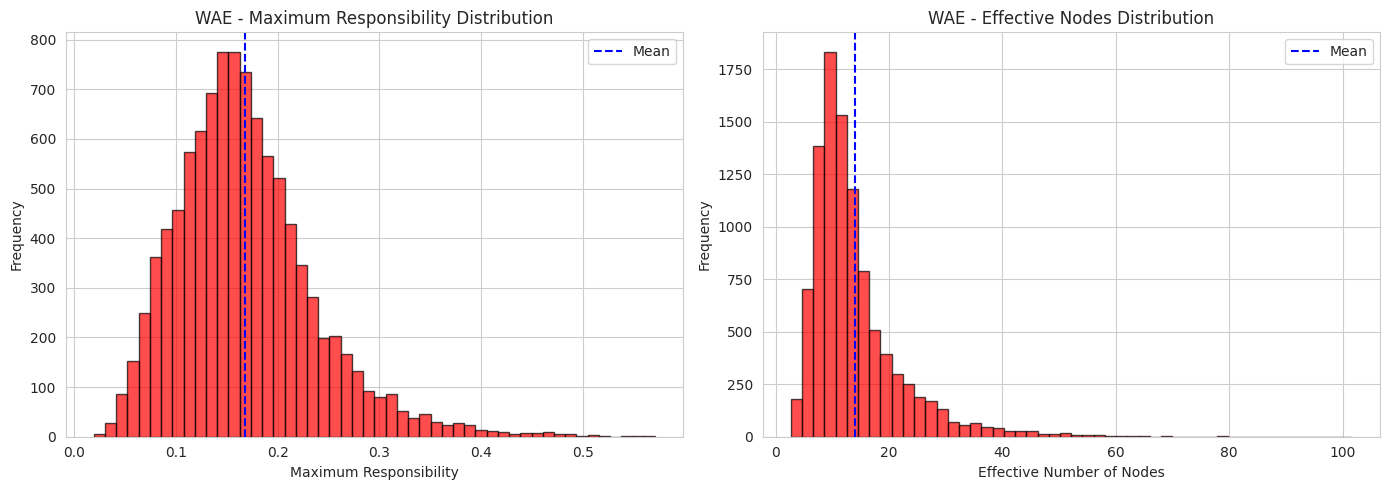

Saved responsibility analysis to /data/aorlov/deepchemography/output/sampling_analysis/peptides_gtm_analysis/gtm_responsibility_analysis.png


In [41]:
# Plot responsibility distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# WAE - Max responsibility
axes[0].hist(max_resp_wae, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[0].set_xlabel('Maximum Responsibility')
axes[0].set_ylabel('Frequency')
axes[0].set_title('WAE - Maximum Responsibility Distribution')
axes[0].axvline(max_resp_wae.mean(), color='blue', linestyle='--', label='Mean')
axes[0].legend()

# WAE - Effective nodes
axes[1].hist(eff_nodes_wae, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1].set_xlabel('Effective Number of Nodes')
axes[1].set_ylabel('Frequency')
axes[1].set_title('WAE - Effective Nodes Distribution')
axes[1].axvline(eff_nodes_wae.mean(), color='blue', linestyle='--', label='Mean')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'gtm_responsibility_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved responsibility analysis to {RESULTS_DIR / 'gtm_responsibility_analysis.png'}")

## 6. Region Sampling

Generate peptides from specific regions of the GTM space.

In [42]:
def sample_from_gtm_region(gtm_model, scaler, decoder_model, vocab, region_coords, z_scaled, responsibilities, n_samples=10):
    """Sample peptides from specific GTM region.
    
    Args:
        gtm_model: Trained GTM model
        scaler: StandardScaler used for latent vectors
        decoder_model: WAE decoder
        vocab: Vocabulary for decoding
        region_coords: List of (y, x) coordinates in GTM grid
        z_scaled: Scaled latent vectors (original data)
        responsibilities: Responsibility matrix (num_samples, num_nodes)
        n_samples: Number of samples per coordinate
    """
    samples = []
    grid_size = int(np.sqrt(GTM_CONFIG['num_nodes']))
    
    for coord in region_coords:
        # Get the node index from grid coordinates
        node_idx = coord[0] * grid_size + coord[1]
        
        # Find data points that are close to this node
        node_responsibilities = responsibilities[:, node_idx]
        
        # Get indices of points with high responsibility for this node
        top_indices = np.argsort(node_responsibilities)[-50:]  # Top 50 points
        
        # Sample from the high-dimensional latent vectors of these points
        for _ in range(n_samples):
            # Randomly select one of the high-responsibility points
            idx = np.random.choice(top_indices)
            z_sample = z_scaled[idx] + np.random.randn(z_scaled.shape[1]) * 0.1
            
            # Inverse transform scaling
            z_sample = scaler.inverse_transform(z_sample.reshape(1, -1))
            
            # Decode to peptide sequence
            try:
                z_tensor = torch.FloatTensor(z_sample).to(DEVICE)
                result = decode_latent(decoder_model, vocab, z_tensor, sample_mode='categorical', temp=1.0)
                samples.append(result[0])
            except Exception as e:
                print(f"Error decoding: {e}")
                samples.append("ERROR")
    
    return samples

print("Region sampling function defined")
print("Uses deepchemography.peptides.decode_latent() for sequence generation")

Region sampling function defined
Uses deepchemography.peptides.decode_latent() for sequence generation


In [43]:
# Sample from high-density modes
print("Sampling from WAE high-density modes...")
wae_mode_samples = sample_from_gtm_region(
    gtm_wae,
    scaler_wae,
    wae_model,
    wae_vocab,
    modes_wae[:5],  # Top 5 modes
    z_wae_scaled,
    responsibilities_wae,
    n_samples=5
)

print(f"\nGenerated {len(wae_mode_samples)} WAE samples")

# Display some samples
print("\nWAE mode samples:")
for i, seq in enumerate(wae_mode_samples[:5]):
    print(f"  {i+1}. {seq}")

Sampling from WAE high-density modes...

Generated 25 WAE samples

WAE mode samples:
  1. A E T Q V P R R K S Q K N V Q R S G A S S
  2. A E T Q V Q P R K S K A K N Q V I R S G A S S
  3. A G R A I L A S R R N N K R A R R L A S
  4. M A K A A K A K K A K A P K K K K A A K K K K
  5. A A A D I A S R V G G V K V V T K A F L L L K


In [44]:
# Sample from different property regions
def identify_property_regions(df, property_name, n_quantiles=4):
    """Identify GTM regions with different property values."""
    quantiles = np.linspace(0, 1, n_quantiles + 1)
    property_quantiles = df[property_name].quantile(quantiles)
    
    regions = {}
    for i in range(n_quantiles):
        mask = (df[property_name] >= property_quantiles.iloc[i]) & \
               (df[property_name] < property_quantiles.iloc[i + 1])
        regions[f'Q{i+1}'] = df[mask]
    
    return regions

if 'hydrophobicity' in df_wae.columns:
    hydrophobic_regions = identify_property_regions(df_wae, 'hydrophobicity', n_quantiles=4)
    
    print("Hydrophobicity regions:")
    for name, region in hydrophobic_regions.items():
        print(f"  {name}: {len(region)} points, "
              f"mean={region['hydrophobicity'].mean():.3f}")

Hydrophobicity regions:
  Q1: 2442 points, mean=0.131
  Q2: 2522 points, mean=0.196
  Q3: 2504 points, mean=0.239
  Q4: 2531 points, mean=0.313


## 8. Export Results

Save GTM models, figures, and region-specific samples.

In [45]:
# Save GTM model
import pickle

print("Saving GTM model...")

with open(RESULTS_DIR / 'gtm_wae_model.pkl', 'wb') as f:
    pickle.dump({
        'model': gtm_wae,
        'scaler': scaler_wae,
        'config': GTM_CONFIG
    }, f)

print(f"Saved GTM model to {RESULTS_DIR}")

Saving GTM model...
Saved GTM model to /data/aorlov/deepchemography/output/sampling_analysis/peptides_gtm_analysis


In [46]:
# Save mode information
print("Saving mode information...")

modes_info = {
    'wae': {
        'coordinates': modes_wae.tolist(),
        'densities': densities_wae,
        'threshold': float(threshold_wae)
    }
}

import json
with open(RESULTS_DIR / 'gtm_modes.json', 'w') as f:
    json.dump(modes_info, f, indent=2)

print(f"Saved mode information to {RESULTS_DIR / 'gtm_modes.json'}")

Saving mode information...
Saved mode information to /data/aorlov/deepchemography/output/sampling_analysis/peptides_gtm_analysis/gtm_modes.json


In [47]:
# Create summary report
summary = f"""
GTM Analysis Summary
====================

Configuration:
- Number of nodes: {GTM_CONFIG['num_nodes']}
- Number of basis functions: {GTM_CONFIG['num_basis_functions']}
- Regularization: {GTM_CONFIG['reg_coeff']}
- Basis width: {GTM_CONFIG['basis_width']}
- Maximum iterations: {GTM_CONFIG['max_iter']}

WAE Results:
- Dataset size: {len(z_wae)}
- Latent dimension: {z_wae.shape[1]}
- Average log-likelihood: {llhs_wae.mean().item():.4f}
- Number of modes: {len(modes_wae)}

Output Files:
- GTM model: gtm_wae_model.pkl
- Embeddings: embeddings_wae.npz
- Analysis DataFrame: gtm_analysis_wae.csv
- Visualizations: *.png, *.html
- Mode information: gtm_modes.json

Results saved to: {RESULTS_DIR}
"""

with open(RESULTS_DIR / 'summary.txt', 'w') as f:
    f.write(summary)

print(summary)


GTM Analysis Summary

Configuration:
- Number of nodes: 900
- Number of basis functions: 100
- Regularization: 100
- Basis width: 1
- Maximum iterations: 200

WAE Results:
- Dataset size: 10000
- Latent dimension: 100
- Average log-likelihood: -134.3509
- Number of modes: 90

Output Files:
- GTM model: gtm_wae_model.pkl
- Embeddings: embeddings_wae.npz
- Analysis DataFrame: gtm_analysis_wae.csv
- Visualizations: *.png, *.html
- Mode information: gtm_modes.json

Results saved to: /data/aorlov/deepchemography/output/sampling_analysis/peptides_gtm_analysis



## Summary

This notebook implemented a GTM analysis workflow for the Peptide WAE model using the `deepchemography.peptides` API:

1. **Setup**: Loaded WAE model via `load_peptide_model()`
2. **Data Preparation**: Encoded peptides via `encode_peptide()` and standardized latent vectors
3. **GTM Training**: Trained a GTM model with 225 nodes and 100 basis functions
4. **Visualization**: Created interactive 2D projections colored by peptide properties
5. **Landscape Analysis**: Identified modes, analyzed density patterns and responsibilities
6. **Region Sampling**: Generated peptides from specific GTM regions via `decode_latent()`
7. **Comparison**: Compared GTM with t-SNE and UMAP using silhouette scores
8. **Export**: Saved models, embeddings, figures, and analysis results